In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pyreadr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report




### Carga de datos 

In [849]:

archivo = '../Data/listings.RData'
data_raw = pyreadr.read_r(archivo)
data_airbnb = data_raw['listings'].copy()


In [850]:


print("Dataset shape")
print(data_airbnb.shape)
print()
print("Dataset vista")
display(data_airbnb.head() )

Dataset shape
(171748, 80)

Dataset vista


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [851]:
data_airbnb['price_clean']= ( data_airbnb['price'] .astype(str) .str.replace(r'[$,]', '', regex=True)  .str.strip() )

data_airbnb['price_clean'] = pd.to_numeric(data_airbnb['price_clean'], errors='coerce')

data_airbnb = data_airbnb[  data_airbnb['price_clean'].notna() & (data_airbnb['price_clean'] > 0) ].copy()


print("shape limpia:", data_airbnb.shape)
print(data_airbnb['price_clean'].describe())

shape limpia: (76246, 81)
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_clean, dtype: float64


In [852]:
q1 = data_airbnb['price_clean'].quantile(0.25)
q3 =data_airbnb['price_clean'].quantile(0.75 )
iqr = q3 - q1

limite_superior= q3 + 1.5 * iqr

data_sin_outliers = data_airbnb[ data_airbnb['price_clean'] <= limite_superior ].copy()

print("shape sin outliers:", data_sin_outliers.shape)
print()
print(data_sin_outliers['price_clean'].describe())

shape sin outliers: (68737, 81)

count    68737.000000
mean       209.363458
std        128.664537
min          8.000000
25%        114.000000
50%        177.000000
75%        274.000000
max        635.000000
Name: price_clean, dtype: float64


features

In [853]:
features = [ 'accommodates',
    'bedrooms' ,
    'beds' ,
    'bathrooms',
    'number_of_reviews' ,
    'availability_365'
]

features = [f for f in features if f in data_sin_outliers.columns]

print("Features comunes:" , features )

Features comunes: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'availability_365']


In [854]:
X = data_sin_outliers[features].copy()
y_real = data_sin_outliers['price_clean'].copy()

print("Shape X:", X.shape )
print("Shape y:", y_real.shape )

Shape X: (68737, 6)
Shape y: (68737,)


Imputar

In [855]:
imputer= SimpleImputer(strategy='mean')

X= pd.DataFrame( imputer.fit_transform(X), columns=features, index=X.index)

print(" nulos por columna después de imputar:")
print()
print(X.isnull().sum())

 nulos por columna después de imputar:

accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
availability_365     0
dtype: int64


C:\Users\belen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\belen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


separar 80 / 20

In [856]:
X_train, X_test, y_train_real, y_test_real = train_test_split(
    X ,
    y_real ,
    test_size= 0.20,
    random_state= 42
)

print("train:", X_train.shape , y_train_real.shape )
print("test: ", X_test.shape , y_test_real.shape )

train: (54989, 6) (54989,)
test:  (13748, 6) (13748,)


escalar

In [857]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = features,index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = features,index=X_test.index)

discretizar

In [858]:
n_bins = 15

discretizer = KBinsDiscretizer(n_bins=n_bins, encode = 'ordinal',strategy='quantile')

y_train_bins = discretizer.fit_transform( y_train_real.to_numpy().reshape(-1, 1) ).astype(int).ravel()

print("observaciones por bin en train:")
print(pd.Series(y_train_bins).value_counts().sort_index())

observaciones por bin en train:
0     3550
1     3636
2     3705
3     3578
4     3847
5     3497
6     3776
7     3599
8     3803
9     3572
10    3749
11    3591
12    3738
13    3571
14    3777
Name: count, dtype: int64


C:\Users\belen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


# 1, 2 y 3. Modelo de regresión usando bayes

In [859]:
modelo_nb_reg = GaussianNB()
modelo_nb_reg.fit(X_train_scaled, y_train_bins)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [860]:
y_pred_bins = modelo_nb_reg.predict(X_test_scaled)

print(" clases predichas:" )
print(y_pred_bins[:10 ])

 clases predichas:
[ 1  2  1  1 14  1 11  1  4  2]


In [861]:
y_train_bins_series =pd.Series( y_train_bins, index=y_train_real.index )
y_train_real_series =pd.Series( y_train_real, index=y_train_real.index )

bin_means = y_train_real_series.groupby(y_train_bins_series).mean()
media_global = y_train_real.mean()

y_pred_nb_reg = np.array([ bin_means.get(bin_id, media_global)
    for bin_id in y_pred_bins
])

In [862]:
mae_nb = mean_absolute_error(y_test_real, y_pred_nb_reg)
mse_nb = mean_squared_error(y_test_real, y_pred_nb_reg)
rmse_nb = np.sqrt(mse_nb)
r2_nb = r2_score(y_test_real, y_pred_nb_reg)

print("Naive Bayes para regresión")
print(f"MAE:  {mae_nb:.4f}")
print(f"MSE:  {mse_nb:.4f}")
print(f"RMSE: {rmse_nb:.4f}")
print(f"R2:   {r2_nb:.4f}")

Naive Bayes para regresión
MAE:  99.9960
MSE:  19266.3516
RMSE: 138.8033
R2:   -0.1656


In [863]:
comparacion_nb = pd.DataFrame({ 'Real': y_test_real.values, 'Predicho': y_pred_nb_reg })

comparacion_nb['Error'] =comparacion_nb['Real'] - comparacion_nb['Predicho']
comparacion_nb['Error_abs'] =comparacion_nb['Error'].abs()

display(comparacion_nb.head() )

,Real,Predicho,Error,Error_abs
0,233.0,75.444994,157.555006,157.555006
1,89.0,93.968421,-4.968421,4.968421
2,225.0,75.444994,149.555006,149.555006
3,249.0,75.444994,173.555006,173.555006
4,289.0,527.783691,-238.783691,238.783691


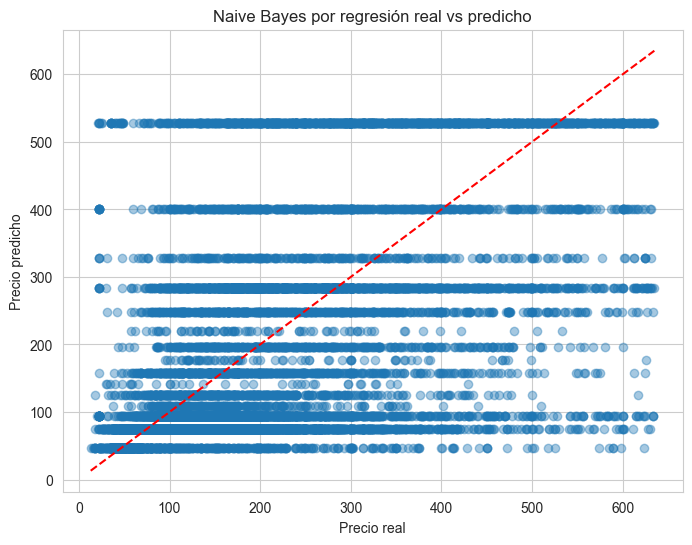

In [864]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_nb_reg, alpha=0.4)
plt.plot( [y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()],
    'r--'
)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Naive Bayes por regresión real vs predicho")
plt.show()

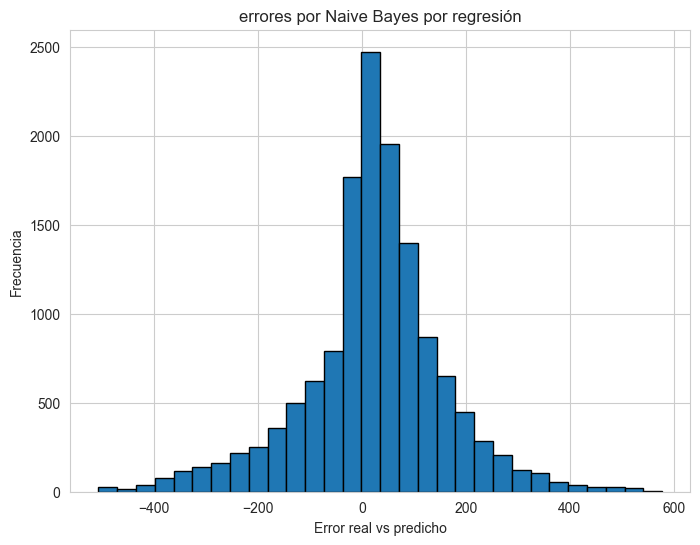

In [865]:
errores_nb = y_test_real - y_pred_nb_reg

plt.figure(figsize=(8,6))
plt.hist(errores_nb, bins=30, edgecolor='black')
plt.xlabel("Error real vs predicho")
plt.ylabel("Frecuencia")
plt.title("errores por Naive Bayes por regresión")
plt.show()

#### regresión lineal

In [866]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train_real)

y_pred_lr = modelo_lr.predict(X_test)


mae_lr = mean_absolute_error(y_test_real, y_pred_lr)
mse_lr = mean_squared_error(y_test_real, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_real, y_pred_lr)

print("Regresión lineal:")
print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")

Regresión lineal:
MAE: 81.7587
MSE: 11596.5869
RMSE: 107.6875
R2: 0.2984


# 4. modelo de clasificación

0 = barata, 1 = media, 2 = cara

In [ ]:
q_bajo = y_train_real.quantile(0.33 )
q_alto = y_train_real.quantile(0.66 )

bins = [ 0, q_bajo , q_alto , y_train_real.max() ]
labels = [0 , 1 , 2 ]   

y_train_class = pd.cut( y_train_real, bins=bins, labels=labels, include_lowest = True ).astype(int)

y_test_class = pd.cut( y_test_real, bins=bins, labels=labels ,  include_lowest = True ).astype(int)

print("distribución en train:")
print(y_train_class.value_counts().sort_index())

distribución en train:
price_clean
0    18316
1    18020
2    18653
Name: count, dtype: int64


In [ ]:
modelo_nb_clf = GaussianNB()
modelo_nb_clf.fit( X_train_scaled, y_train_class)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
y_pred_clf = modelo_nb_clf.predict(X_test_scaled )

métricas

# 5 eficiencia del algoritmo

In [ ]:
accuracy = accuracy_score(y_test_class, y_pred_clf )

print(f"accuracy: {accuracy:.4f}")
print()
print("reporte de clasificación")
print(classification_report(y_test_class, y_pred_clf) )

accuracy: 0.5185

reporte de clasificación
              precision    recall  f1-score   support

           0       0.49      0.82      0.61      4554
           1       0.40      0.20      0.27      4512
           2       0.64      0.53      0.58      4682

    accuracy                           0.52     13748
   macro avg       0.51      0.52      0.49     13748
weighted avg       0.51      0.52      0.49     13748



# 6. matriz de confusión

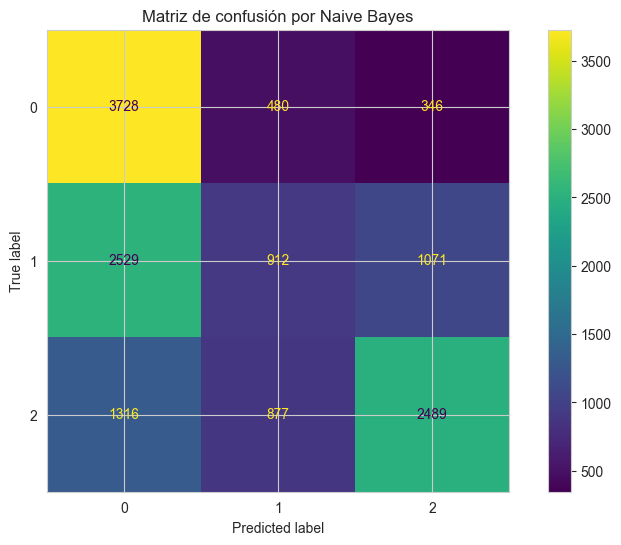

In [885]:
cm = confusion_matrix(y_test_class, y_pred_clf)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.title("Matriz de confusión por Naive Bayes")
plt.show()